In [1]:
# import tarfile
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
# with tarfile.open("stlabels.tgz", "r:gz") as tar:
#     tar.extractall("stlabels_extracted", filter="data")
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from scipy.stats import chi2_contingency

In [2]:

df_7cups = pd.read_csv("stlabels_extracted/stlabels/7cups/gemini_3labels.csv")
df_7_cups_labels=pd.read_csv("stlabels_extracted/stlabels/7cups/gpt_topics.csv",index_col=False)
df_7_cups_labels=df_7_cups_labels[["pid","topic"]]
df_7cups=pd.merge(df_7cups,df_7_cups_labels,on="pid", how="left").reset_index(drop=True)


df_7cups_missing=df_7cups[df_7cups["topic"].isna()].reset_index(drop=True)
df_7cups_missing = df_7cups_missing.drop(columns=["topic"])

df_7cups = df_7cups[~df_7cups["topic"].isna()].reset_index(drop=True)

df_7cups_missing_annotated=pd.read_csv("stlabels_extracted/stlabels/7cups/gpt_topics_missing.csv", index_col=False)
df_7cups_missing_annotated=df_7cups_missing_annotated[["pid","topic"]]
df_7cups_missing=pd.merge(df_7cups_missing,df_7cups_missing_annotated,on="pid", how="left").reset_index(drop=True)

df_7cups = pd.concat([df_7cups, df_7cups_missing], axis=0).reset_index(drop=True)

In [4]:
df_mindline = pd.read_csv("stlabels_extracted/stlabels/mindline/hangouts_gemini_3labels.csv")
df_mindline_with_topics=pd.read_csv("stlabels_extracted/stlabels/mindline/mindline_hangouts.csv")
df_mindline_with_topics=df_mindline_with_topics[["pid","type"]]
df_mindline_with_topics["pid"]=df_mindline_with_topics["pid"].astype(str)
df_mindline["pid"]=df_mindline["pid"].astype(str)
df_mindline=pd.merge(df_mindline,df_mindline_with_topics,on="pid", how="left").reset_index(drop=True)
df_mindline["type"].value_counts().sum()
df_mindline = df_mindline.rename(columns={'type': 'topic'})

In [5]:
df_mindline_to_save=df_mindline[["pid","#stlabels","label1","label2","label3","topic"]]
df_7cups_to_save=df_7cups[["pid","#stlabels","EMS1","EMS2","EMS3","topic"]]
df_mindline_to_save.to_csv("data_for_OSF_upload/raw_data/mindline_data.csv")
df_7cups_to_save.to_csv("data_for_OSF_upload/raw_data/7cups_data.csv")

In [6]:

# =========================================================
# 2) STANDARDIZE SCHEMA LABELS
# =========================================================
schema_map = {
    "NEGATIVITY/PESSIMISM": "NEGATIVITY/PESSIMISM (NP)",
    "NEGATIVITY/PESSIMISM (NP)": "NEGATIVITY/PESSIMISM (NP)",

    "EMOTIONAL DEPRIVATION": "EMOTIONAL DEPRIVATION (ED)",
    "EMOTIONAL DEPRIVATION (ED)": "EMOTIONAL DEPRIVATION (ED)",

    "DEFECTIVENESS/SHAME": "DEFECTIVENESS/SHAME (DS)",
    "DEFECTIVENESS/SHAME (DS)": "DEFECTIVENESS/SHAME (DS)",

    "SOCIAL ISOLATION/ALIENATION": "SOCIAL ISOLATION/ALIENATION (SI)",
    "SOCIAL ISOLATION/ALIENATION (SI)": "SOCIAL ISOLATION/ALIENATION (SI)",

    "INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE": "INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS)",
    "INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS)": "INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS)",

    "EMOTIONAL INHIBITION": "EMOTIONAL INHIBITION (EI)",
    "EMOTIONAL INHIBITION (EI)": "EMOTIONAL INHIBITION (EI)",

    "DEPENDENCE/INCOMPETENCE": "DEPENDENCE/INCOMPETENCE (DI)",
    "DEPENDENCE/INCOMPETENCE (DI)": "DEPENDENCE/INCOMPETENCE (DI)",

    "MISTRUST/ABUSE": "MISTRUST/ABUSE (MA)",
    "MISTRUST/ABUSE (MA)": "MISTRUST/ABUSE (MA)",

    "FAILURE TO ACHIEVE": "FAILURE TO ACHIEVE (FA)",
    "FAILURE TO ACHIEVE (FA)": "FAILURE TO ACHIEVE (FA)",

    "ENMESHMENT/UNDEVELOPED SELF": "ENMESHMENT/UNDEVELOPED SELF (EM)",
    "ENMESHMENT/UNDEVELOPED SELF (EM)": "ENMESHMENT/UNDEVELOPED SELF (EM)",

    "SUBJUGATION": "SUBJUGATION (SB)",
    "SUBJUGATION (SB)": "SUBJUGATION (SB)",

    "UNRELENTING STANDARDS": "UNRELENTING STANDARDS/HYPERCRITICALNESS (US)",
    "UNRELENTING STANDARDS (US)": "UNRELENTING STANDARDS/HYPERCRITICALNESS (US)",
    "UNRELENTING STANDARDS/HYPERCRITICALNESS (US)": "UNRELENTING STANDARDS/HYPERCRITICALNESS (US)",

    "VULNERABILITY TO HARM OR ILLNESS": "VULNERABILITY TO HARM OR ILLNESS (VH)",
    "VULNERABILITY TO HARM OR ILLNESS (VH)": "VULNERABILITY TO HARM OR ILLNESS (VH)",

    "SELF-SACRIFICE": "SELF-SACRIFICE (SS)",
    "SELF-SACRIFICE (SS)": "SELF-SACRIFICE (SS)",

    "APPROVAL-SEEKING/RECOGNITION-SEEKING": "APPROVAL-SEEKING/RECOGNITION-SEEKING (AS)",
    "APPROVAL-SEEKING/RECOGNITION-SEEKING (AS)": "APPROVAL-SEEKING/RECOGNITION-SEEKING (AS)",

    "ABANDONMENT/INSTABILITY": "ABANDONMENT/INSTABILITY (AB)",
    "ABANDONMENT/INSTABILITY (AB)": "ABANDONMENT/INSTABILITY (AB)",

    "PUNITIVENESS": "PUNITIVENESS (PU)",
    "PUNITIVENESS (PU)": "PUNITIVENESS (PU)",

    "ENTITLEMENT/GRANDIOSITY": "ENTITLEMENT/GRANDIOSITY (ET)",
    "ENTITLEMENT/GRANDIOSITY (ET)": "ENTITLEMENT/GRANDIOSITY (ET)",
}

# =========================================================
# 3) RESHAPE TO LONG FORMAT
# =========================================================
ems_cols_7 = ["EMS1", "EMS2", "EMS3"]
ems_cols_m = ["label1", "label2", "label3"]

df7_long = (
    df_7cups
    .melt(id_vars=["pid", "topic"], value_vars=ems_cols_7, value_name="schema")
    .dropna(subset=["schema"])
    .copy()
)

dfm_long = (
    df_mindline
    .melt(id_vars=["pid", "topic"], value_vars=ems_cols_m, value_name="schema")
    .dropna(subset=["schema"])
    .copy()
)

df7_long["schema"] = df7_long["schema"].replace(schema_map)
dfm_long["schema"] = dfm_long["schema"].replace(schema_map)

df7_long["dataset"] = "7cups"
dfm_long["dataset"] = "mindline"


In [7]:


def get_z_tests(df7_long,dfm_long):


    # =========================================================
    # 4) COMBINE BOTH DATASETS
    # =========================================================
    df_long = pd.concat([df7_long, dfm_long], ignore_index=True)

    # Optional: inspect any labels that were not standardized
    all_valid = set(schema_map.values())
    unknown_labels = sorted(set(df_long["schema"].dropna()) - all_valid)
    print("Unknown / unmapped labels:")
    print(unknown_labels)
    print()

    # =========================================================
    # 5) CREATE BINARY POST x SCHEMA MATRIX
    #    Each row = one post
    #    Each schema column = 1 if post contains schema, else 0
    # =========================================================
    binary = (
        df_long.assign(present=1)
        .pivot_table(
            index=["dataset", "pid"],
            columns="schema",
            values="present",
            aggfunc="max",
            fill_value=0
        )
        .reset_index()
    )

    # =========================================================
    # 6) SPLIT BACK INTO THE TWO DATASETS
    # =========================================================
    binary_7 = binary[binary["dataset"] == "7cups"].copy()
    binary_m = binary[binary["dataset"] == "mindline"].copy()

    n1 = len(binary_7)   # number of posts in 7cups
    n2 = len(binary_m)   # number of posts in mindline

    print(f"Number of posts in 7cups: {n1}")
    print(f"Number of posts in mindline: {n2}")
    print()

    # =========================================================
    # 7) RUN TWO-PROPORTION Z-TEST FOR EACH SCHEMA
    # =========================================================
    schema_cols = [c for c in binary.columns if c not in ["dataset", "pid"]]

    results = []

    for schema in schema_cols:
        count_7 = int(binary_7[schema].sum())
        count_m = int(binary_m[schema].sum())

        z, p = proportions_ztest([count_7, count_m], [n1, n2])

        results.append({
            "schema": schema,
            "count_7cups": count_7,
            "count_mindline": count_m,
            "prop_7cups": count_7 / n1,
            "prop_mindline": count_m / n2,
            "diff": (count_7 / n1) - (count_m / n2),
            "z": z,
            "p": p
        })

    results = pd.DataFrame(results)

    # =========================================================
    # 8) MULTIPLE-TESTING CORRECTION
    # =========================================================
    results["p_adj"] = multipletests(results["p"], method="fdr_bh")[1]

    # =========================================================
    # 9) SORT RESULTS
    # =========================================================
    results = results.sort_values(["p_adj", "p", "schema"]).reset_index(drop=True)
    results["p_reject"] = results["p_adj"] < 0.05


    table = pd.crosstab(df_long["dataset"], df_long["schema"])
    chi2, p_global, dof, expected = chi2_contingency(table)

    chi_results={"Chi2:": chi2,"p:": p_global,"dof": dof}
    return(results,chi_results)

    
def plot_differences(results_all, df7_long, dfm_long, plot_name, legends=False):

    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    # -------------------------------------------------
    # DOMAIN MAPPING
    # -------------------------------------------------
    schema_domain_map = {
        "ABANDONMENT/INSTABILITY (AB)": "Disconnection & Rejection",
        "MISTRUST/ABUSE (MA)": "Disconnection & Rejection",
        "EMOTIONAL DEPRIVATION (ED)": "Disconnection & Rejection",
        "DEFECTIVENESS/SHAME (DS)": "Disconnection & Rejection",
        "SOCIAL ISOLATION/ALIENATION (SI)": "Disconnection & Rejection",

        "DEPENDENCE/INCOMPETENCE (DI)": "Impaired Autonomy & Performance",
        "VULNERABILITY TO HARM OR ILLNESS (VH)": "Impaired Autonomy & Performance",
        "ENMESHMENT/UNDEVELOPED SELF (EM)": "Impaired Autonomy & Performance",
        "FAILURE TO ACHIEVE (FA)": "Impaired Autonomy & Performance",

        "ENTITLEMENT/GRANDIOSITY (ET)": "Impaired Limits",
        "INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS)": "Impaired Limits",

        "SUBJUGATION (SB)": "Other-Directedness",
        "SELF-SACRIFICE (SS)": "Other-Directedness",
        "APPROVAL-SEEKING/RECOGNITION-SEEKING (AS)": "Other-Directedness",

        "NEGATIVITY/PESSIMISM (NP)": "Overvigilance & Inhibition",
        "EMOTIONAL INHIBITION (EI)": "Overvigilance & Inhibition",
        "UNRELENTING STANDARDS/HYPERCRITICALNESS (US)": "Overvigilance & Inhibition",
        "PUNITIVENESS (PU)": "Overvigilance & Inhibition",
    }

    # -------------------------------------------------
    # DOMAIN COLORS USING TAB20
    # -------------------------------------------------
    domain_order = [
        "Disconnection & Rejection",
        "Impaired Autonomy & Performance",
        "Impaired Limits",
        "Other-Directedness",
        "Overvigilance & Inhibition",
    ]

    cmap = plt.get_cmap("tab20")

    domain_colors = {
        domain: cmap(i)
        for i, domain in enumerate(domain_order)
    }

    # -------------------------------------------------
    # PREP DATA
    # -------------------------------------------------
    df_long = pd.concat([df7_long, dfm_long], ignore_index=True)

    binary = (
        df_long.assign(present=1)
        .pivot_table(
            index=["dataset", "pid"],
            columns="schema",
            values="present",
            aggfunc="max",
            fill_value=0
        )
        .reset_index()
    )

    binary_7 = binary[binary["dataset"] == "7cups"].copy()
    binary_m = binary[binary["dataset"] == "mindline"].copy()

    plot_df = results_all.copy()

    plot_df["diff_rev"] = plot_df["prop_mindline"] - plot_df["prop_7cups"]

    n1 = len(binary_7)
    n2 = len(binary_m)

    plot_df["se"] = np.sqrt(
        plot_df["prop_mindline"] * (1 - plot_df["prop_mindline"]) / n2 +
        plot_df["prop_7cups"] * (1 - plot_df["prop_7cups"]) / n1
    )

    plot_df["ci95"] = 1.96 * plot_df["se"]
    plot_df["sig_adj"] = plot_df["p_adj"] < 0.05

    # assign domain and colors
    plot_df["domain"] = plot_df["schema"].map(schema_domain_map)
    plot_df["color"] = plot_df["domain"].map(domain_colors)

    plot_df["color"] = plot_df["color"].fillna("#7f7f7f")

    plot_df = plot_df.sort_values("diff_rev").reset_index(drop=True)

    # -------------------------------------------------
    # PLOT
    # -------------------------------------------------
    fig, ax = plt.subplots(figsize=(18, 8.5))

    y = np.arange(len(plot_df))

    for row_i, row in enumerate(plot_df.itertuples()):

        ax.errorbar(
            x=row.diff_rev,
            y=row_i,
            xerr=row.ci95,
            fmt="o",
            color=row.color,
            ecolor=row.color,
            elinewidth=2,
            capsize=3,
            capthick=1.5,
            markersize=7,
            markerfacecolor=row.color if row.sig_adj else "white",
            markeredgecolor=row.color,
            markeredgewidth=1.8,
            zorder=3
        )

    ax.axvline(0, color="black", linewidth=1.3)

    # -------------------------------------------------
    # LABELS
    # -------------------------------------------------
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["schema"], fontsize=11)

    ax.set_xlabel("Difference in proportion of posts (Mindline − 7cups)", fontsize=12)

    ax.grid(axis="x", color="#D9D9D9", linewidth=0.8, alpha=0.7)
    ax.grid(axis="y", visible=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", labelsize=11)

    xmin = (plot_df["diff_rev"] - plot_df["ci95"]).min() - 0.01
    xmax = (plot_df["diff_rev"] + plot_df["ci95"]).max() + 0.01

    ax.set_xlim(xmin, xmax)

    # arrows
    ax.text(
        0.2, 0.995,
        "← 7cups higher ←",
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=11
    )

    ax.text(
        0.9, 0.995,
        "→ Mindline higher →",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=11
    )

    # -------------------------------------------------
    # SIGNIFICANCE LEGEND
    # -------------------------------------------------
    sig_legend = [
        Line2D([0],[0], marker="o", color="black",
               markerfacecolor="black", markersize=7, linewidth=0,
               label="Significant after FDR adjustment"),

        Line2D([0],[0], marker="o", color="black",
               markerfacecolor="white", markersize=7, linewidth=0,
               label="Not significant after FDR adjustment")
    ]

    ax.legend(
        handles=sig_legend,
        loc="lower right",
        frameon=True,
        edgecolor="none",
        fontsize=10
    )

    # -------------------------------------------------
    # DOMAIN LEGEND
    # -------------------------------------------------
    if legends:

        domain_handles = [
            Patch(facecolor=domain_colors[d], edgecolor="black",
                  linewidth=0.4, label=d)
            for d in domain_order
        ]

        fig.legend(
            handles=domain_handles,
            title="Schema domains",
            loc="upper left",
            bbox_to_anchor=(0.80, 0.92),
            frameon=True,
            edgecolor="none",
            fontsize=10,
            title_fontsize=10
        )

        plt.subplots_adjust(left=0.33, right=0.78, top=0.92, bottom=0.10)

    else:
        plt.subplots_adjust(left=0.33, right=0.97, top=0.92, bottom=0.10)

    # -------------------------------------------------
    # SAVE
    # -------------------------------------------------
    os.makedirs("plots/differences", exist_ok=True)

    plt.savefig(
        f"plots/differences/{plot_name}.png",
        dpi=900,
        bbox_inches="tight"
    )

    plt.show()

In [8]:
results_all,chi_results_all=get_z_tests(df7_long,dfm_long)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
# =========================================================
# 11) OPTIONAL: SAVE RESULTS
# =========================================================
results_all.to_csv("schema_platform_comparison_binary_post_level.csv", index=False)
results_all


Unknown / unmapped labels:
[]

Number of posts in 7cups: 574
Number of posts in mindline: 769



,schema,count_7cups,count_mindline,prop_7cups,prop_mindline,diff,z,p,p_adj,p_reject
0,SOCIAL ISOLATION/ALIENATION (SI),223,173,0.388502,0.224967,0.163534,6.501945,7.928827e-11,1.427189e-09,True
1,UNRELENTING STANDARDS/HYPERCRITICALNESS (US),41,116,0.071429,0.150845,-0.079417,-4.481018,7.428784e-06,6.685905e-05,True
2,FAILURE TO ACHIEVE (FA),104,216,0.181185,0.280884,-0.099700,-4.242655,2.208909e-05,1.325345e-04,True
3,MISTRUST/ABUSE (MA),79,160,0.137631,0.208062,-0.070432,-3.338429,8.425353e-04,3.791409e-03,True
4,SUBJUGATION (SB),46,103,0.080139,0.133940,-0.053801,-3.105637,1.898699e-03,6.835317e-03,True
5,DEFECTIVENESS/SHAME (DS),141,247,0.245645,0.321196,-0.075552,-3.021928,2.511700e-03,7.535101e-03,True
6,ABANDONMENT/INSTABILITY (AB),74,69,0.128920,0.089727,0.039193,2.303596,2.124532e-02,5.463083e-02,False
7,EMOTIONAL DEPRIVATION (ED),199,223,0.346690,0.289987,0.056703,2.214503,2.679417e-02,6.028688e-02,False
8,EMOTIONAL INHIBITION (EI),72,70,0.125436,0.091027,0.034408,2.028634,4.249553e-02,8.499107e-02,False
9,DEPENDENCE/INCOMPETENCE (DI),61,58,0.106272,0.075423,0.030849,1.968050,4.906228e-02,8.831210e-02,False


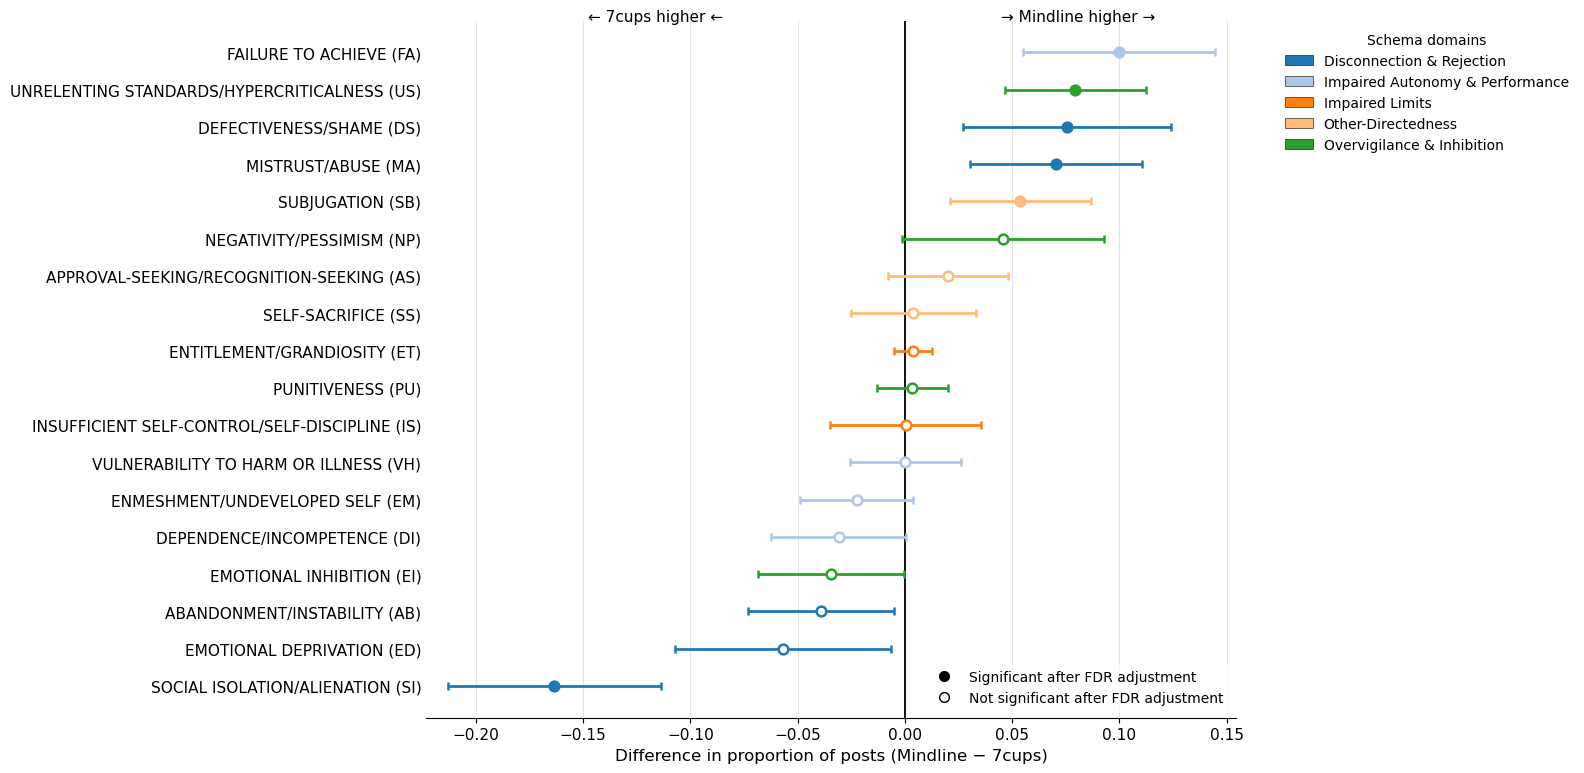

In [9]:
plot_differences(results_all,df7_long,dfm_long,"all", True)

### Family and Friends

In [10]:
def filter_by_topic(df7_long, dfm_long, topic_value):
    df7_filtered = df7_long[df7_long["topic"] == topic_value].reset_index(drop=True)
    dfm_filtered = dfm_long[dfm_long["topic"] == topic_value].reset_index(drop=True)
    if df7_filtered.empty or dfm_filtered.empty:
        print("Warning: one of the datasets has 0 rows")
    return (df7_filtered, dfm_filtered)
df7_family, dfm_friends=filter_by_topic(df7_long, dfm_long, "Family and Friends")

In [11]:
results_family,chi_results_family=get_z_tests(df7_family,dfm_friends)
# =========================================================
# 11) OPTIONAL: SAVE RESULTS
# =========================================================
#results_all.to_csv("schema_platform_comparison_binary_post_level.csv", index=False)
results_family

Unknown / unmapped labels:
[]

Number of posts in 7cups: 231
Number of posts in mindline: 71



,schema,count_7cups,count_mindline,prop_7cups,prop_mindline,diff,z,p,p_adj,p_reject
0,SOCIAL ISOLATION/ALIENATION (SI),128,22,0.554113,0.309859,0.244253,3.600077,0.000318,0.004158,True
1,MISTRUST/ABUSE (MA),37,25,0.160173,0.352113,-0.191940,-3.501882,0.000462,0.004158,True
2,SUBJUGATION (SB),19,15,0.082251,0.211268,-0.129017,-3.007995,0.002630,0.015779,True
3,INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS),8,7,0.034632,0.098592,-0.063960,-2.169488,0.030046,0.135206,False
4,UNRELENTING STANDARDS/HYPERCRITICALNESS (US),7,6,0.030303,0.084507,-0.054204,-1.968110,0.049055,0.151739,False
5,PUNITIVENESS (PU),2,3,0.008658,0.042254,-0.033596,-1.940245,0.052350,0.151739,False
6,DEFECTIVENESS/SHAME (DS),44,21,0.190476,0.295775,-0.105298,-1.888121,0.059010,0.151739,False
7,ENTITLEMENT/GRANDIOSITY (ET),0,1,0.000000,0.014085,-0.014085,-1.806746,0.070802,0.159304,False
8,ABANDONMENT/INSTABILITY (AB),50,9,0.216450,0.126761,0.089690,1.667062,0.095502,0.191004,False
9,EMOTIONAL DEPRIVATION (ED),121,31,0.523810,0.436620,0.087190,1.285100,0.198757,0.357763,False


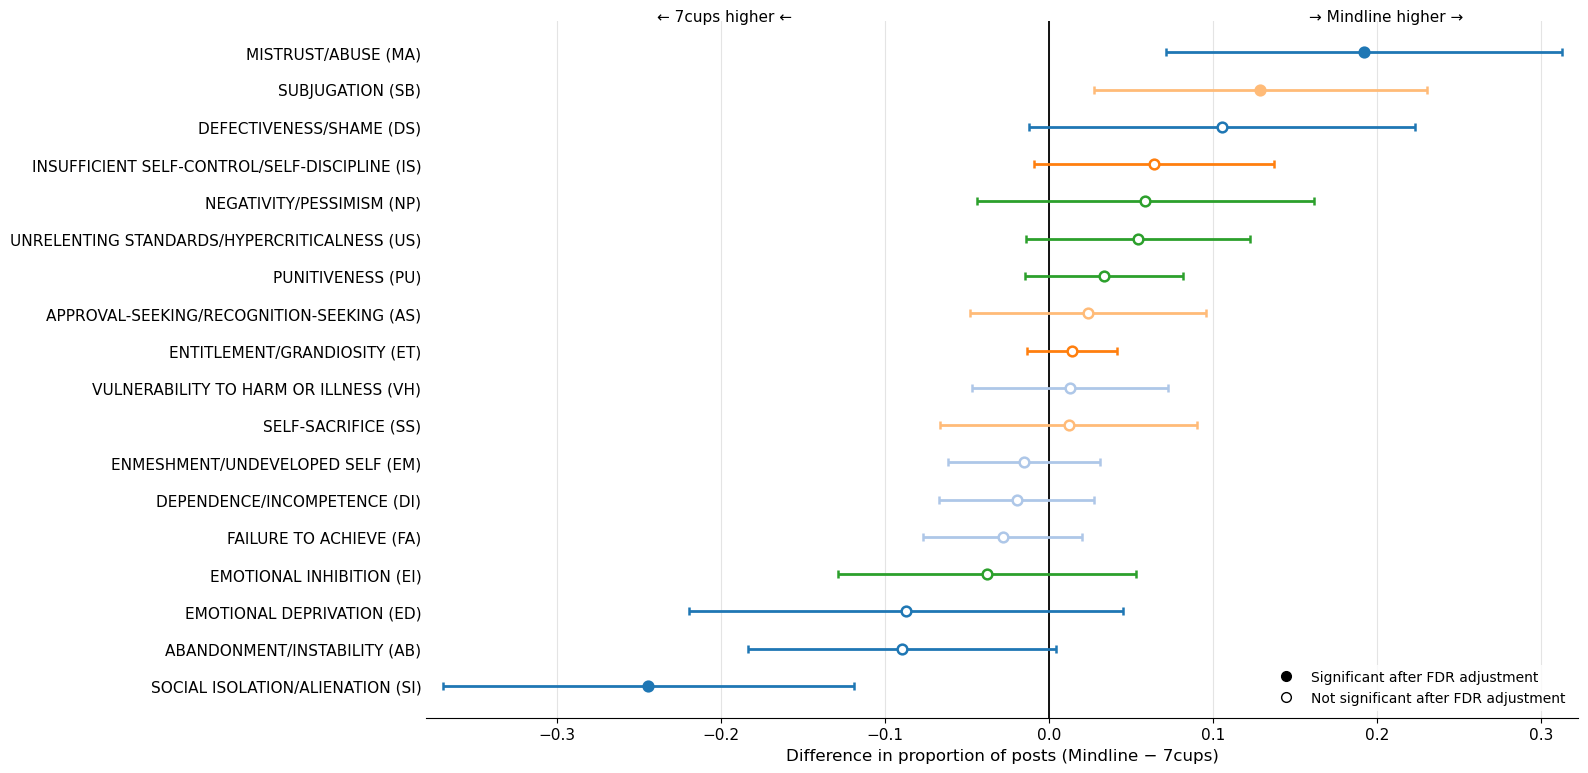

In [12]:
plot_differences(results_family,df7_family,dfm_friends,"Family and Friends")

### Adulting

In [13]:
df7_Adulting, dfm_Adulting=filter_by_topic(df7_long, dfm_long, "Adulting")
results_Adulting,chi_results_Adulting=get_z_tests(df7_Adulting, dfm_Adulting)
# =========================================================
# 11) OPTIONAL: SAVE RESULTS
# =========================================================
#results_all.to_csv("schema_platform_comparison_binary_post_level.csv", index=False)
results_Adulting


Unknown / unmapped labels:
[]

Number of posts in 7cups: 104
Number of posts in mindline: 112



,schema,count_7cups,count_mindline,prop_7cups,prop_mindline,diff,z,p,p_adj,p_reject
0,MISTRUST/ABUSE (MA),4,13,0.038462,0.116071,-0.077610,-2.116502,0.034302,0.421730,False
1,SUBJUGATION (SB),4,12,0.038462,0.107143,-0.068681,-1.925822,0.054127,0.421730,False
2,PUNITIVENESS (PU),3,0,0.028846,0.000000,0.028846,1.810048,0.070288,0.421730,False
3,DEPENDENCE/INCOMPETENCE (DI),22,15,0.211538,0.133929,0.077610,1.512663,0.130365,0.473499,False
4,INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS),16,10,0.153846,0.089286,0.064560,1.456987,0.145120,0.473499,False
5,SOCIAL ISOLATION/ALIENATION (SI),31,24,0.298077,0.214286,0.083791,1.412397,0.157833,0.473499,False
6,ENMESHMENT/UNDEVELOPED SELF (EM),14,9,0.134615,0.080357,0.054258,1.291742,0.196447,0.505148,False
7,SELF-SACRIFICE (SS),5,10,0.048077,0.089286,-0.041209,-1.190416,0.233883,0.511534,False
8,EMOTIONAL DEPRIVATION (ED),12,19,0.115385,0.169643,-0.054258,-1.136453,0.255767,0.511534,False
9,ENTITLEMENT/GRANDIOSITY (ET),1,0,0.009615,0.000000,0.009615,1.040160,0.298266,0.536878,False


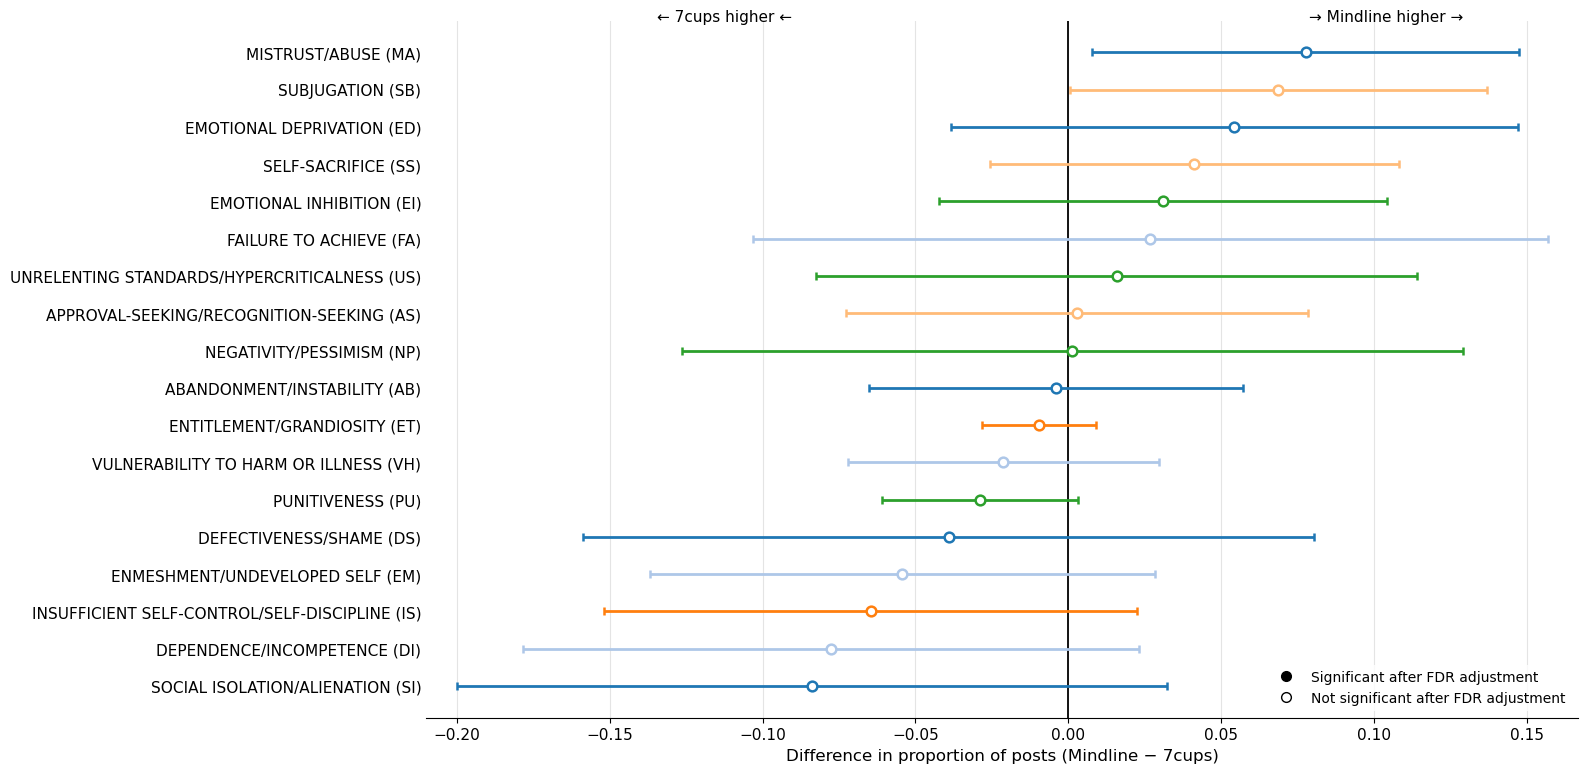

In [14]:
plot_differences(results_Adulting,df7_Adulting, dfm_Adulting,"Adulting")

### Rants

In [15]:
df7_Rants, dfm_Rants=filter_by_topic(df7_long, dfm_long, "Rants")
results_Rants,chi_results_Rants=get_z_tests(df7_Rants, dfm_Rants)
# =========================================================
# 11) OPTIONAL: SAVE RESULTS
# =========================================================
#results_all.to_csv("schema_platform_comparison_binary_post_level.csv", index=False)
results_Rants


Unknown / unmapped labels:
[]

Number of posts in 7cups: 54
Number of posts in mindline: 276



,schema,count_7cups,count_mindline,prop_7cups,prop_mindline,diff,z,p,p_adj,p_reject
0,PUNITIVENESS (PU),5,7,0.092593,0.025362,0.067230,2.413621,0.015795,0.284308,False
1,SUBJUGATION (SB),3,46,0.055556,0.166667,-0.111111,-2.099978,0.035731,0.321577,False
2,APPROVAL-SEEKING/RECOGNITION-SEEKING (AS),1,18,0.018519,0.065217,-0.046699,-1.347280,0.177890,0.538177,False
3,VULNERABILITY TO HARM OR ILLNESS (VH),1,17,0.018519,0.061594,-0.043076,-1.274756,0.202396,0.538177,False
4,UNRELENTING STANDARDS/HYPERCRITICALNESS (US),2,24,0.037037,0.086957,-0.049919,-1.245246,0.213041,0.538177,False
5,INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS),9,30,0.166667,0.108696,0.057971,1.206814,0.227504,0.538177,False
6,EMOTIONAL DEPRIVATION (ED),15,100,0.277778,0.362319,-0.084541,-1.192361,0.233120,0.538177,False
7,SOCIAL ISOLATION/ALIENATION (SI),10,72,0.185185,0.260870,-0.075684,-1.177015,0.239190,0.538177,False
8,ENMESHMENT/UNDEVELOPED SELF (EM),4,11,0.074074,0.039855,0.034219,1.104015,0.269587,0.539174,False
9,MISTRUST/ABUSE (MA),10,66,0.185185,0.239130,-0.053945,-0.861069,0.389200,0.662273,False


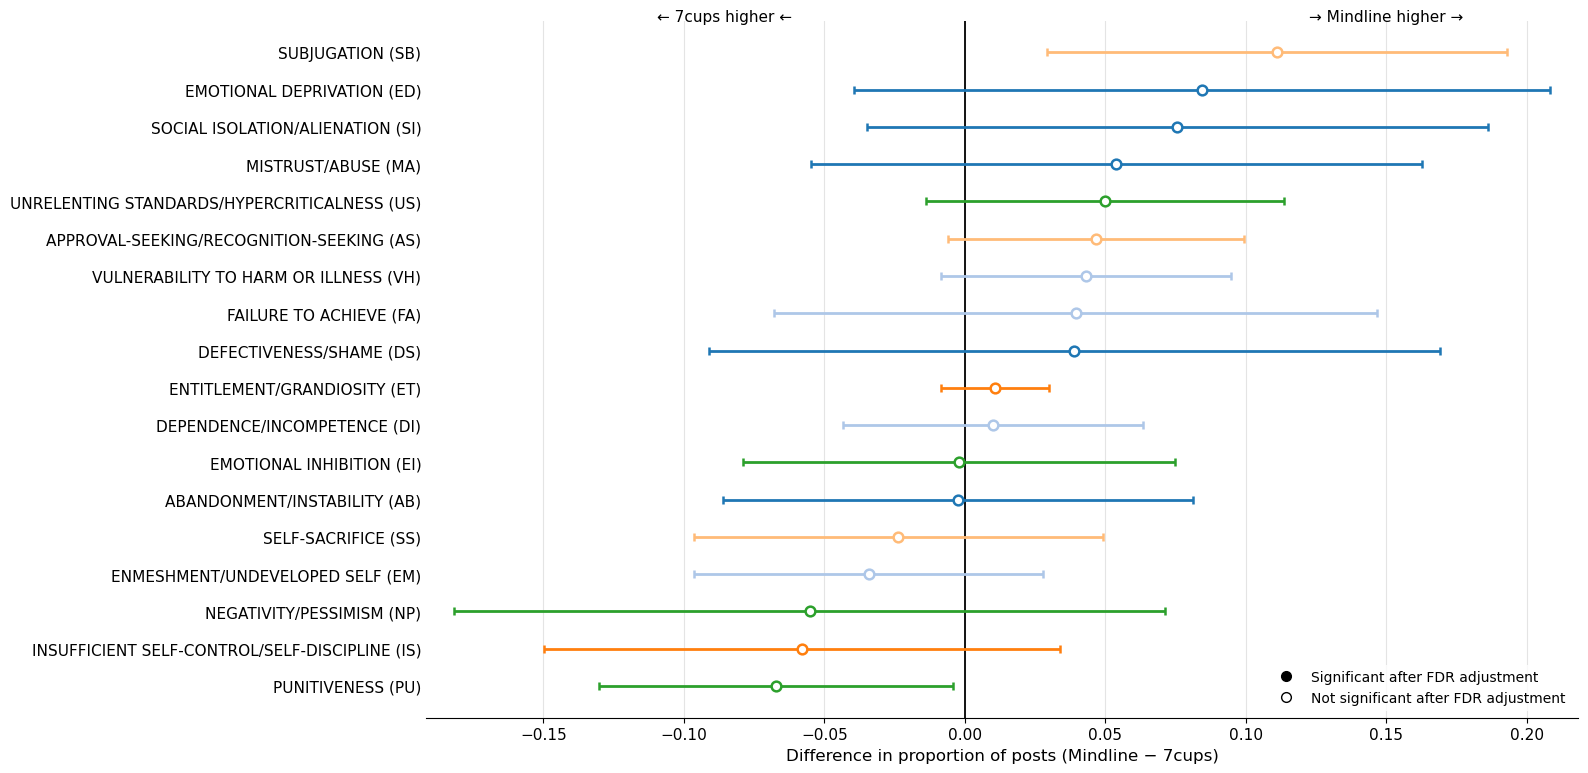

In [16]:
plot_differences(results_Rants,df7_Adulting, dfm_Adulting,"Rants")

### I want to help

In [17]:
df7_I, dfm_I=filter_by_topic(df7_long, dfm_long, "I want to help")
results_I,chi_results_I=get_z_tests(df7_I, dfm_I)
# =========================================================
# 11) OPTIONAL: SAVE RESULTS
# =========================================================
#results_all.to_csv("schema_platform_comparison_binary_post_level.csv", index=False)
results_I


Unknown / unmapped labels:
[]

Number of posts in 7cups: 51
Number of posts in mindline: 29



,schema,count_7cups,count_mindline,prop_7cups,prop_mindline,diff,z,p,p_adj,p_reject
0,NEGATIVITY/PESSIMISM (NP),7,10,0.137255,0.344828,-0.207573,-2.181748,0.029128,0.395231,False
1,UNRELENTING STANDARDS/HYPERCRITICALNESS (US),3,6,0.058824,0.206897,-0.148073,-2.014905,0.043915,0.395231,False
2,MISTRUST/ABUSE (MA),11,2,0.215686,0.068966,0.146721,1.710061,0.087255,0.523528,False
3,SUBJUGATION (SB),4,0,0.078431,0.000000,0.078431,1.547327,0.121784,0.548030,False
4,ABANDONMENT/INSTABILITY (AB),2,3,0.039216,0.103448,-0.064233,-1.140956,0.253888,0.777282,False
5,PUNITIVENESS (PU),2,0,0.039216,0.000000,0.039216,1.080007,0.280139,0.777282,False
6,INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS),14,5,0.274510,0.172414,0.102096,1.031564,0.302276,0.777282,False
7,VULNERABILITY TO HARM OR ILLNESS (VH),6,5,0.117647,0.172414,-0.054767,-0.683794,0.494106,0.989611,False
8,SOCIAL ISOLATION/ALIENATION (SI),13,6,0.254902,0.206897,0.048005,0.485040,0.627648,0.989611,False
9,DEFECTIVENESS/SHAME (DS),10,7,0.196078,0.241379,-0.045301,-0.476147,0.633970,0.989611,False


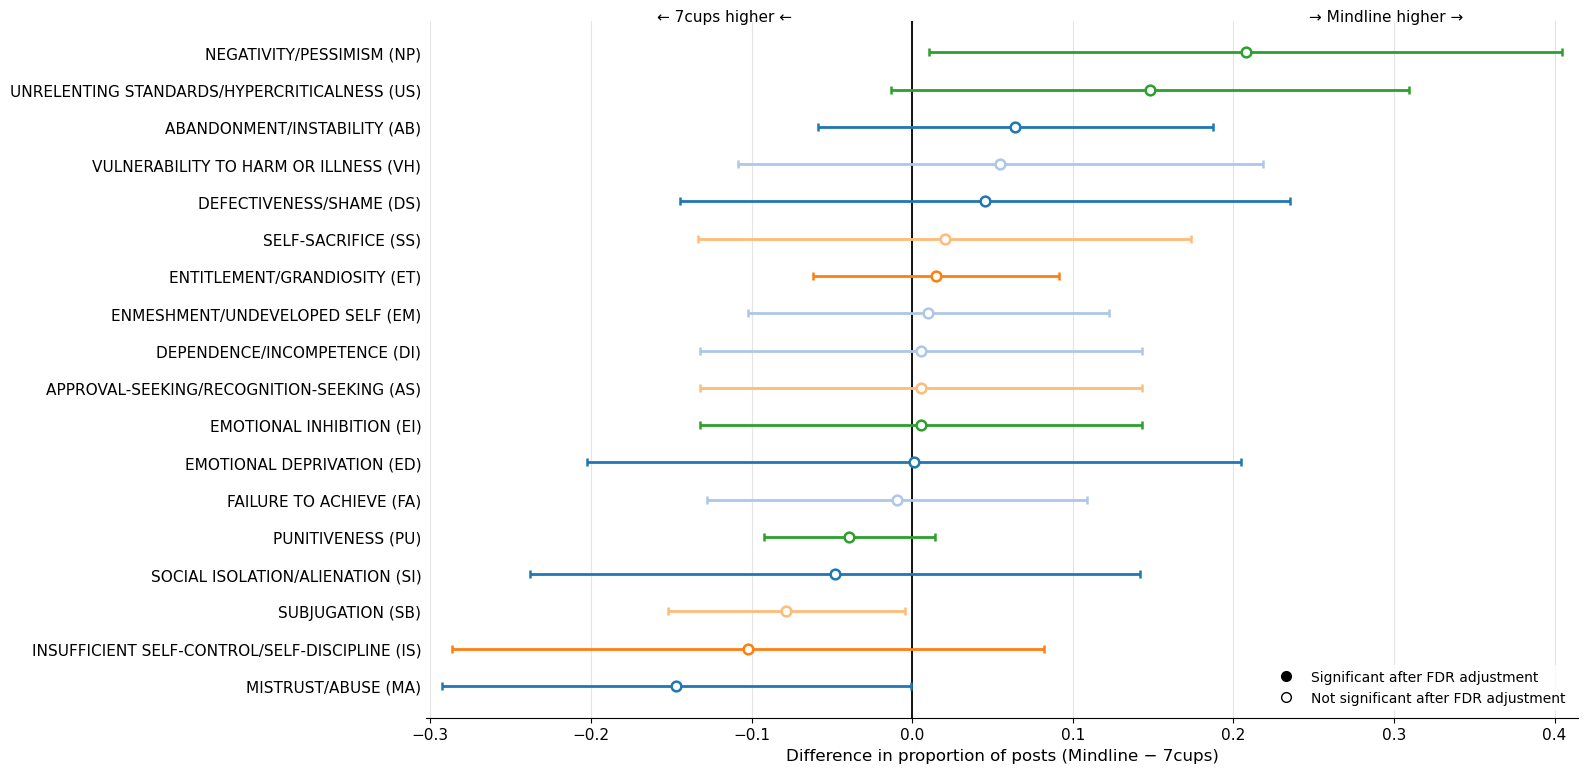

In [18]:
plot_differences(results_I,df7_I, dfm_I,"I want to help")

### My Parents

In [19]:
df7_Parents, dfm_Parents=filter_by_topic(df7_long, dfm_long, "My Parents")
results_Parents,chi_results_Parents=get_z_tests(df7_Parents, dfm_Parents)
# =========================================================
# 11) OPTIONAL: SAVE RESULTS
# =========================================================
#results_all.to_csv("schema_platform_comparison_binary_post_level.csv", index=False)
results_Parents


Unknown / unmapped labels:
[]

Number of posts in 7cups: 36
Number of posts in mindline: 43



,schema,count_7cups,count_mindline,prop_7cups,prop_mindline,diff,z,p,p_adj,p_reject
0,DEPENDENCE/INCOMPETENCE (DI),8,3,0.222222,0.069767,0.152455,1.949348,0.051254,0.472833,False
1,MISTRUST/ABUSE (MA),8,18,0.222222,0.418605,-0.196382,-1.850023,0.064310,0.472833,False
2,INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS),4,1,0.111111,0.023256,0.087855,1.597225,0.110216,0.472833,False
3,EMOTIONAL DEPRIVATION (ED),15,25,0.416667,0.581395,-0.164729,-1.458498,0.144703,0.472833,False
4,PUNITIVENESS (PU),0,2,0.000000,0.046512,-0.046512,-1.310691,0.189962,0.472833,False
5,VULNERABILITY TO HARM OR ILLNESS (VH),0,2,0.000000,0.046512,-0.046512,-1.310691,0.189962,0.472833,False
6,FAILURE TO ACHIEVE (FA),7,4,0.194444,0.093023,0.101421,1.296812,0.194696,0.472833,False
7,NEGATIVITY/PESSIMISM (NP),5,3,0.138889,0.069767,0.069121,1.014233,0.310472,0.561798,False
8,SOCIAL ISOLATION/ALIENATION (SI),6,4,0.166667,0.093023,0.073643,0.980411,0.326883,0.561798,False
9,SELF-SACRIFICE (SS),4,8,0.111111,0.186047,-0.074935,-0.924183,0.355391,0.561798,False


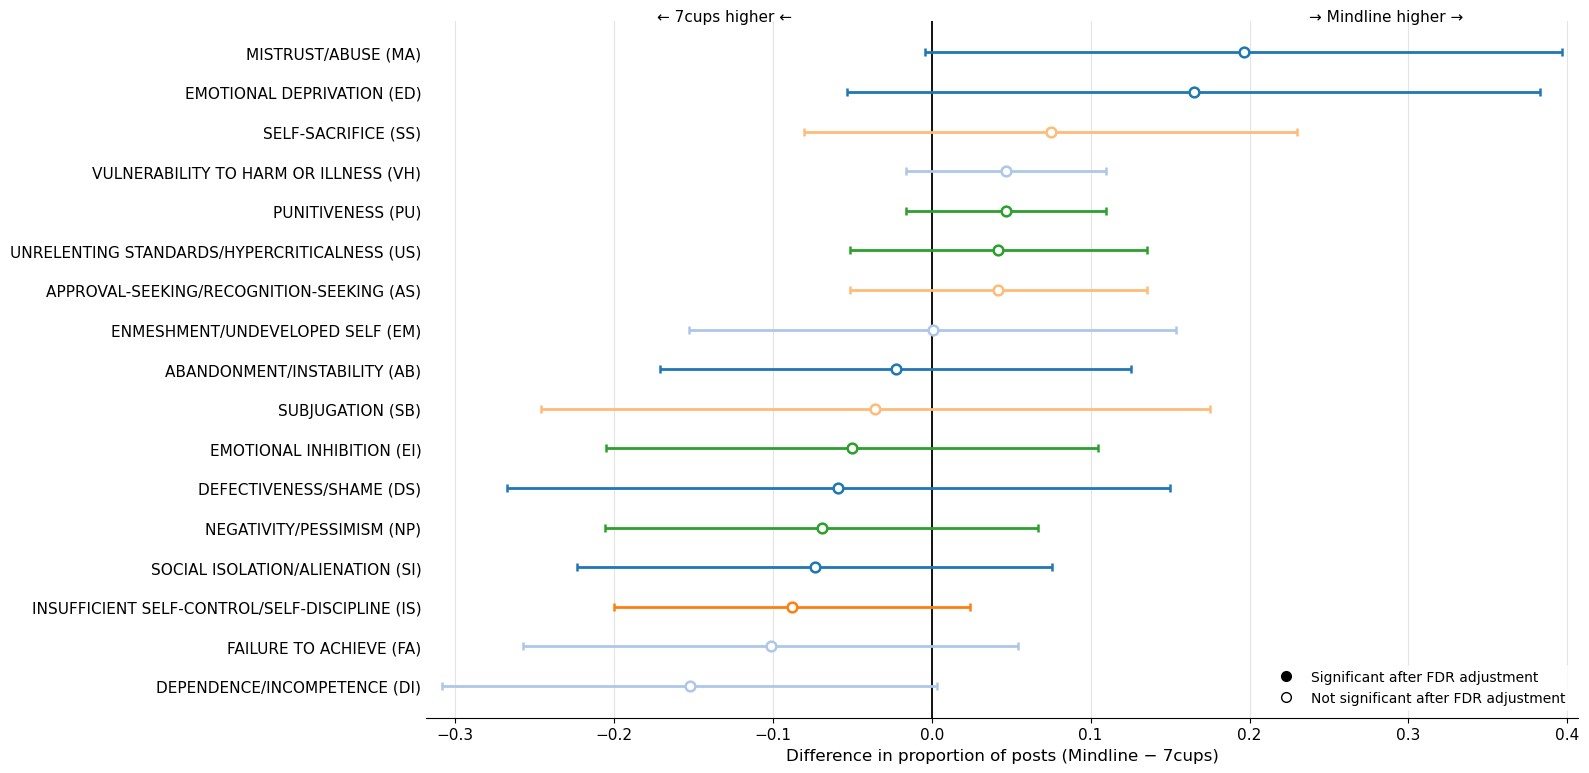

In [20]:
plot_differences(results_Parents,df7_Parents, dfm_Parents,"My Parents")

### Student Life

In [21]:
df7_Student, dfm_Student=filter_by_topic(df7_long, dfm_long, "Student Life")
results_Student,chi_results_Student=get_z_tests(df7_Student, dfm_Student)
# =========================================================
# 11) OPTIONAL: SAVE RESULTS
# =========================================================
#results_all.to_csv("schema_platform_comparison_binary_post_level.csv", index=False)
results_Student


Unknown / unmapped labels:
[]

Number of posts in 7cups: 34
Number of posts in mindline: 151



,schema,count_7cups,count_mindline,prop_7cups,prop_mindline,diff,z,p,p_adj,p_reject
0,SOCIAL ISOLATION/ALIENATION (SI),14,23,0.411765,0.152318,0.259447,3.416886,0.000633,0.011402,True
1,UNRELENTING STANDARDS/HYPERCRITICALNESS (US),6,50,0.176471,0.331126,-0.154655,-1.773330,0.076174,0.685566,False
2,EMOTIONAL DEPRIVATION (ED),8,22,0.235294,0.145695,0.089599,1.280529,0.200359,0.846203,False
3,ENTITLEMENT/GRANDIOSITY (ET),1,1,0.029412,0.006623,0.022789,1.160923,0.245673,0.846203,False
4,ENMESHMENT/UNDEVELOPED SELF (EM),0,5,0.000000,0.033113,-0.033113,-1.075686,0.282068,0.846203,False
5,PUNITIVENESS (PU),0,5,0.000000,0.033113,-0.033113,-1.075686,0.282068,0.846203,False
6,MISTRUST/ABUSE (MA),2,16,0.058824,0.105960,-0.047137,-0.837874,0.402101,0.960462,False
7,VULNERABILITY TO HARM OR ILLNESS (VH),2,5,0.058824,0.033113,0.025711,0.709860,0.477791,0.960462,False
8,APPROVAL-SEEKING/RECOGNITION-SEEKING (AS),3,20,0.088235,0.132450,-0.044215,-0.705931,0.480231,0.960462,False
9,NEGATIVITY/PESSIMISM (NP),8,31,0.235294,0.205298,0.029996,0.387409,0.698453,0.986153,False


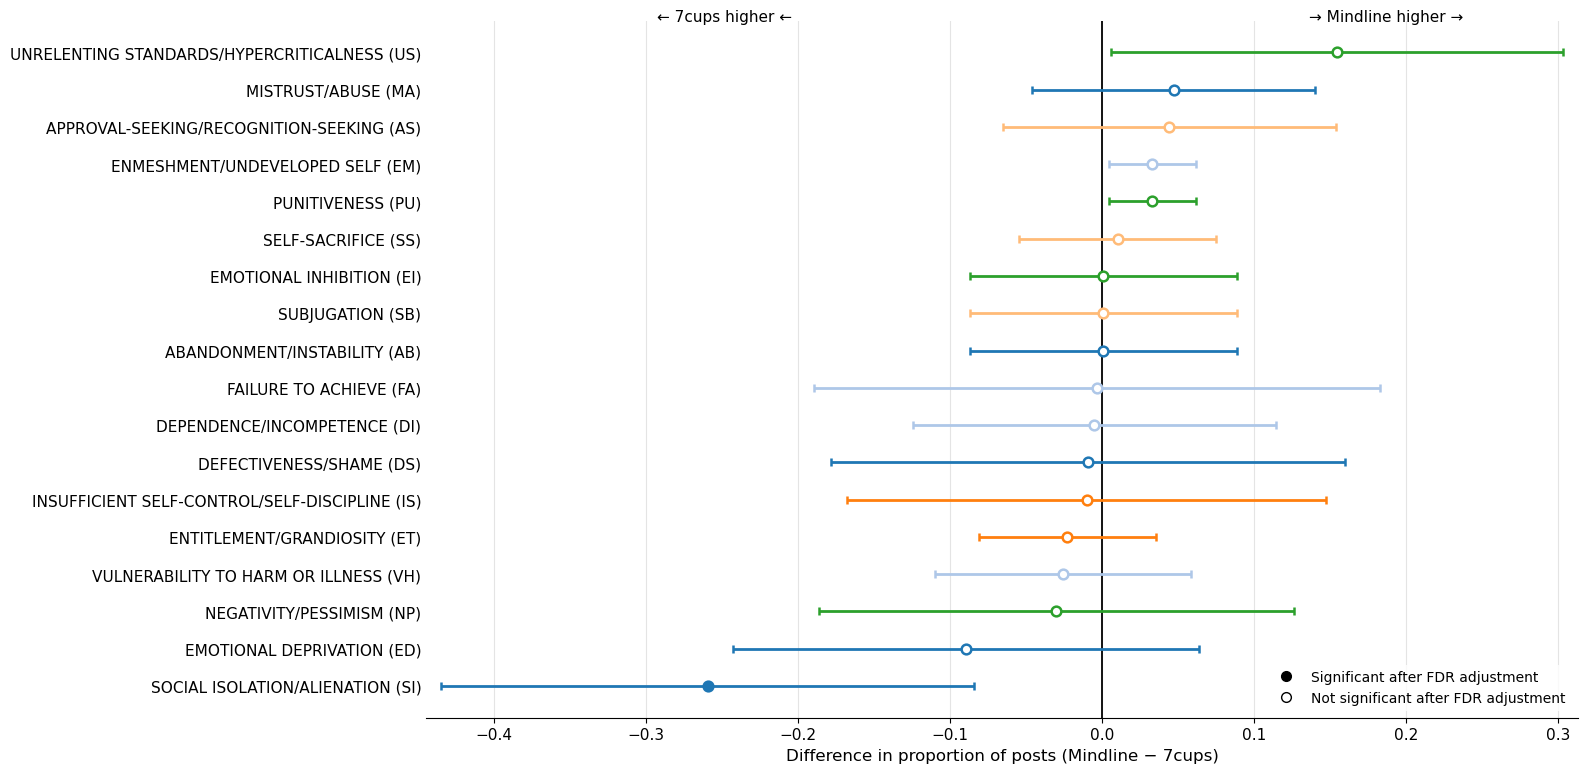

In [22]:
plot_differences(results_Student,df7_Student, dfm_Student,"Student Life")

### Trigger Warnings

In [23]:
df7_Trigger, dfm_Trigger=filter_by_topic(df7_long, dfm_long, "Trigger Warnings")
results_Trigger,chi_results_Trigger=get_z_tests(df7_Trigger, dfm_Trigger)
# =========================================================
# 11) OPTIONAL: SAVE RESULTS
# =========================================================
#results_all.to_csv("schema_platform_comparison_binary_post_level.csv", index=False)
results_Trigger

Unknown / unmapped labels:
[]

Number of posts in 7cups: 26
Number of posts in mindline: 43



,schema,count_7cups,count_mindline,prop_7cups,prop_mindline,diff,z,p,p_adj,p_reject
0,DEPENDENCE/INCOMPETENCE (DI),3,0,0.115385,0.000000,0.115385,2.277512,0.022756,0.260380,False
1,MISTRUST/ABUSE (MA),2,12,0.076923,0.279070,-0.202147,-2.023330,0.043039,0.260380,False
2,SUBJUGATION (SB),0,5,0.000000,0.116279,-0.116279,-1.805394,0.071013,0.260380,False
3,EMOTIONAL DEPRIVATION (ED),5,17,0.192308,0.395349,-0.203041,-1.753756,0.079472,0.260380,False
4,SOCIAL ISOLATION/ALIENATION (SI),11,10,0.423077,0.232558,0.190519,1.666683,0.095577,0.260380,False
5,NEGATIVITY/PESSIMISM (NP),13,13,0.500000,0.302326,0.197674,1.642007,0.100589,0.260380,False
6,ENMESHMENT/UNDEVELOPED SELF (EM),6,4,0.230769,0.093023,0.137746,1.575065,0.115242,0.260380,False
7,INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS),4,2,0.153846,0.046512,0.107335,1.533342,0.125192,0.260380,False
8,VULNERABILITY TO HARM OR ILLNESS (VH),8,7,0.307692,0.162791,0.144902,1.414087,0.157336,0.260380,False
9,PUNITIVENESS (PU),0,3,0.000000,0.069767,-0.069767,-1.377101,0.168481,0.260380,False


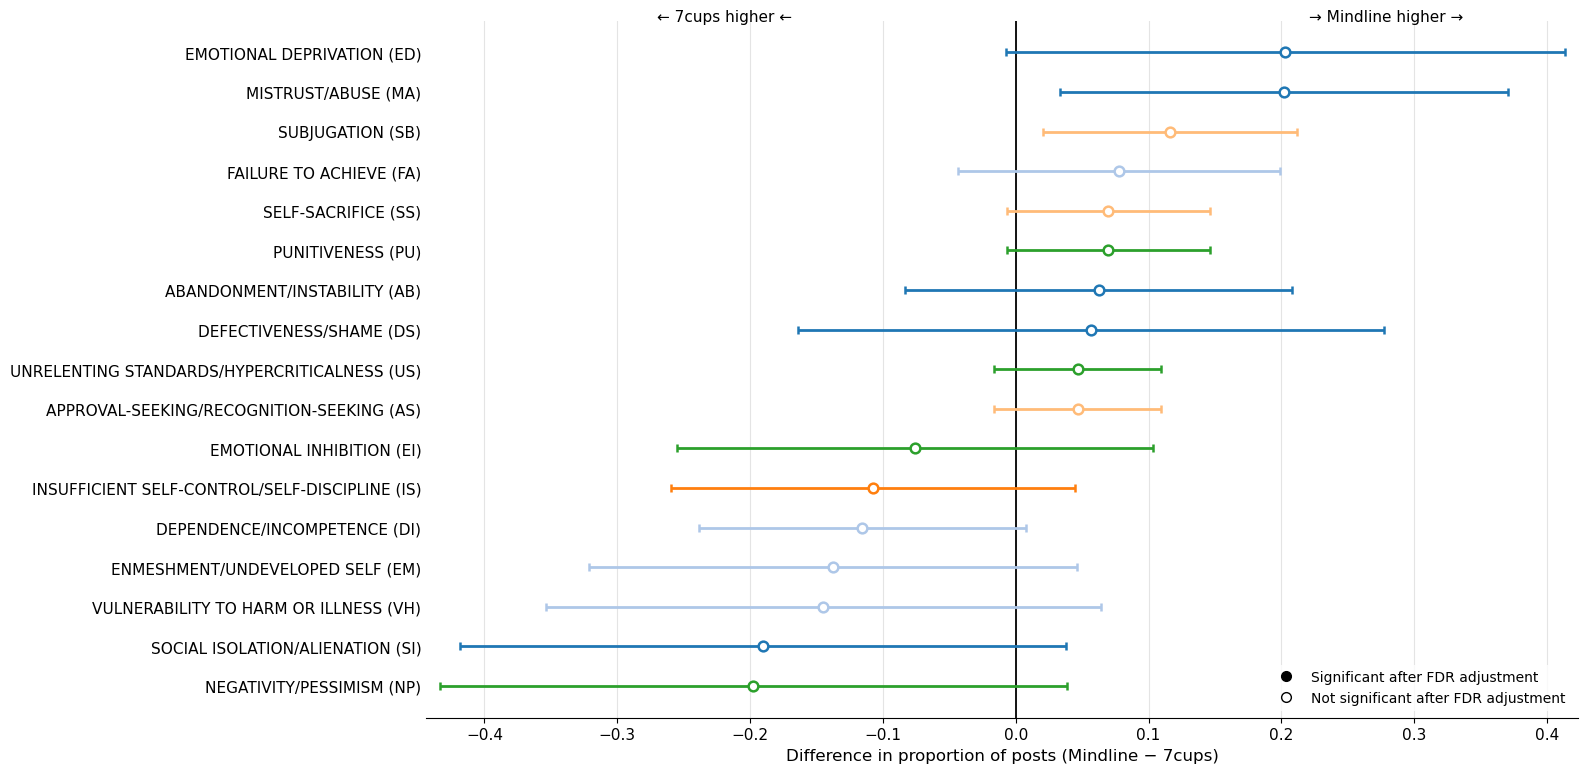

In [24]:
plot_differences(results_Trigger,df7_Trigger, dfm_Trigger,"Trigger Warnings")

### 9 to 5

In [25]:
df7_9, dfm_9=filter_by_topic(df7_long, dfm_long, "9 to 5")
results_9,chi_results_9=get_z_tests(df7_9, dfm_9)
# =========================================================
# 11) OPTIONAL: SAVE RESULTS
# =========================================================
#results_all.to_csv("schema_platform_comparison_binary_post_level.csv", index=False)
results_9


Unknown / unmapped labels:
[]

Number of posts in 7cups: 25
Number of posts in mindline: 31



,schema,count_7cups,count_mindline,prop_7cups,prop_mindline,diff,z,p,p_adj,p_reject
0,EMOTIONAL DEPRIVATION (ED),4,1,0.16,0.032258,0.127742,1.666511,0.095612,0.877888,False
1,EMOTIONAL INHIBITION (EI),4,2,0.16,0.064516,0.095484,1.148456,0.250780,0.877888,False
2,FAILURE TO ACHIEVE (FA),11,18,0.44,0.580645,-0.140645,-1.047101,0.295053,0.877888,False
3,ABANDONMENT/INSTABILITY (AB),0,1,0.00,0.032258,-0.032258,-0.906154,0.364855,0.877888,False
4,ENTITLEMENT/GRANDIOSITY (ET),0,1,0.00,0.032258,-0.032258,-0.906154,0.364855,0.877888,False
5,VULNERABILITY TO HARM OR ILLNESS (VH),3,2,0.12,0.064516,0.055484,0.723838,0.469165,0.877888,False
6,DEPENDENCE/INCOMPETENCE (DI),5,4,0.20,0.129032,0.070968,0.718846,0.472236,0.877888,False
7,INSUFFICIENT SELF-CONTROL/SELF-DISCIPLINE (IS),4,3,0.16,0.096774,0.063226,0.711201,0.476960,0.877888,False
8,SOCIAL ISOLATION/ALIENATION (SI),5,8,0.20,0.258065,-0.058065,-0.511623,0.608915,0.877888,False
9,SUBJUGATION (SB),1,2,0.04,0.064516,-0.024516,-0.405040,0.685448,0.877888,False


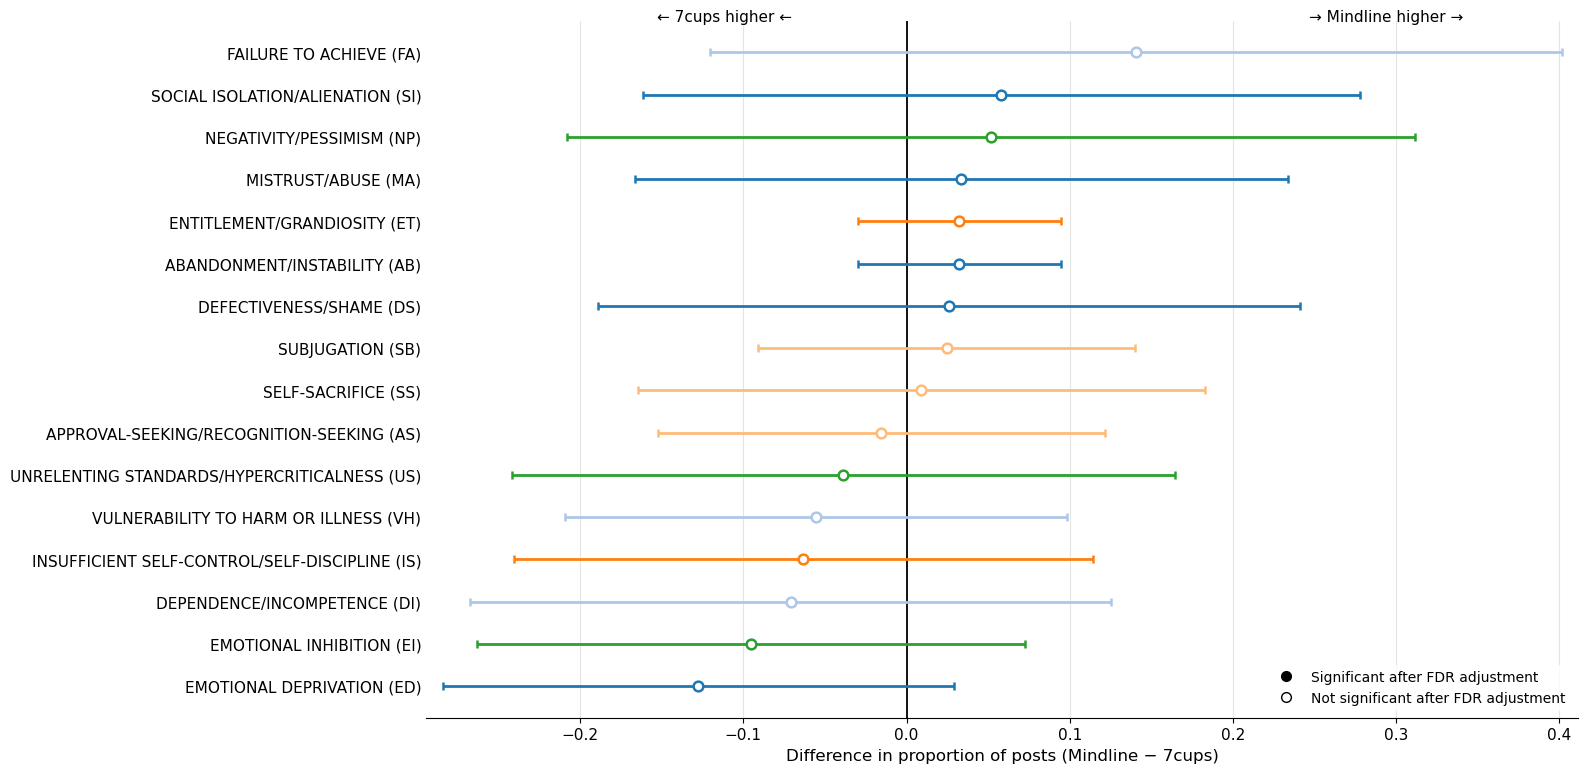

In [26]:
plot_differences(results_9,df7_9, dfm_9,"9 to 5")

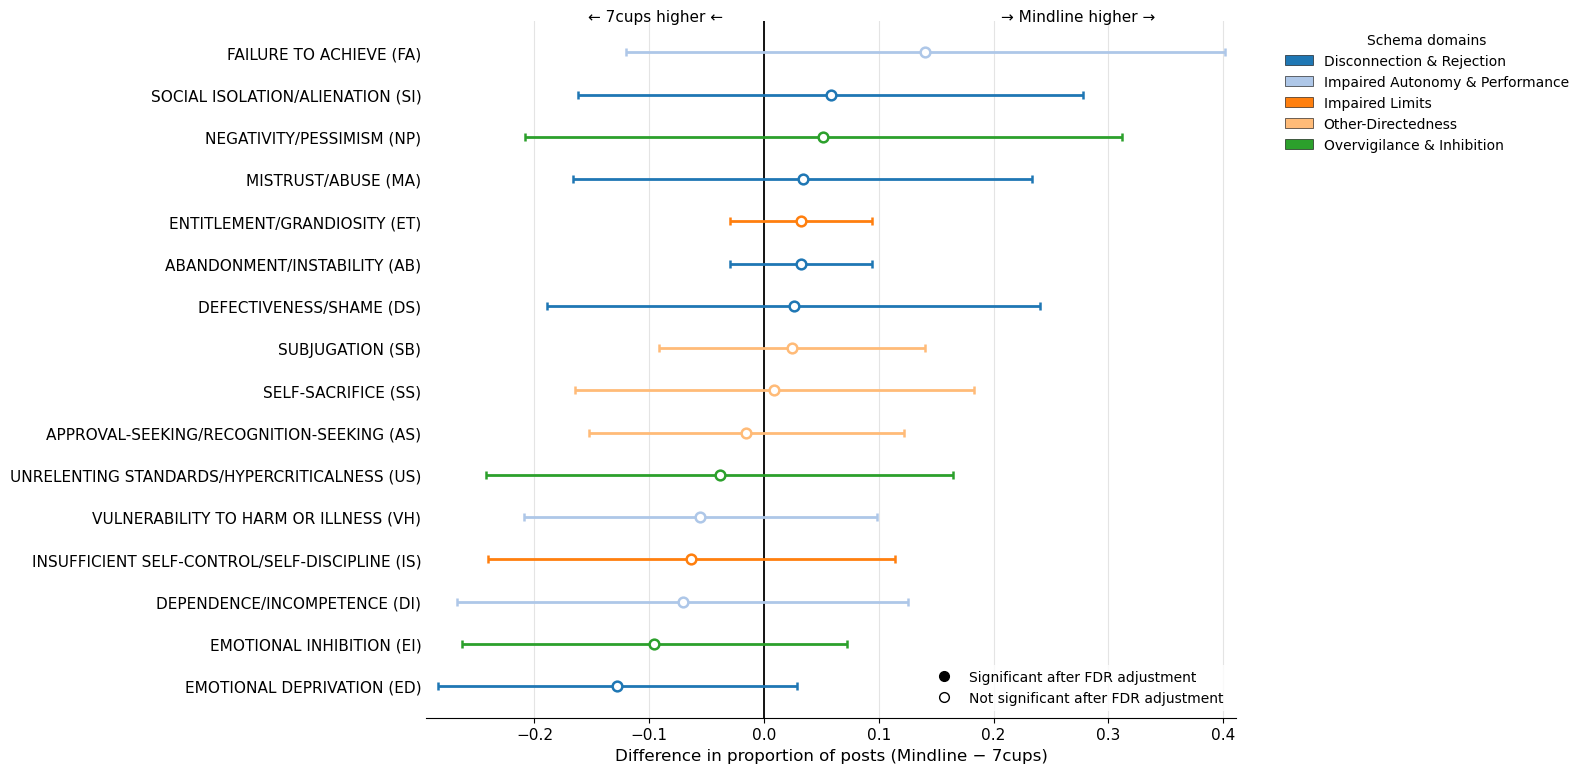

In [27]:
plot_differences(results_9,df7_9, dfm_9,"9 to 5 (2)", True)

### Combining all the data. 

In [28]:
list_of_results = [
    results_all, results_family, results_Adulting, results_Rants,
    results_I, results_Parents, results_Student, results_Trigger, results_9
]

list_of_topics = [
    "All", "Family", "Adulting", "Rants",
    "I want to help", "Parents", "Student Life", "Trigger Warning", "9 to 5"
]

list_of_updated_results = []

for result, topic in zip(list_of_results, list_of_topics):
    result = result.copy()
    result["topic"] = topic
    list_of_updated_results.append(result)


In [29]:
all_results=pd.concat(list_of_updated_results).reset_index(drop=True)
all_results.to_csv("statistical_results.csv",index=False)
all_results.to_csv("data_for_OSF_upload/results/statistical_results.csv",index=False)